# Member Cluster - Model Training

The data that was cleaned and compiled in the previous notebook will be used here to train the member clustering model with machine learning. The trained model will then be used in a separate notebook for the full data pipeline.

## Prepare the data

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Read the CSV
member_data = pd.read_csv('member_data_compiled.csv')

member_data.head()

,member_number,society_status,years_of_service,district_status,district_referral_count,gender,birthdate,district_original_join_date,district_most_recent_join_date,district_latest_end_date,...,former_chapter_count,current_chorus_count,former_chorus_count,current_quartet_count,former_quartet_count,current_chapter_leader_count,former_chapter_leader_count,current_district_leader_count,former_district_leader_count,true_lapses
0,Num_5084,Expired,8,Former,0,Male,1971-01-01 00:00:00,2008-04-22 00:00:00,2015-01-10 00:00:00,2020-01-09 00:00:00,...,2,0,1,0,2,0,0,0,0,1
1,Num_4577,Expired,6,Former,0,Male,1953-09-20 00:00:00,2009-01-22 00:00:00,2009-01-22 00:00:00,2013-10-02 00:00:00,...,1,0,1,0,1,0,0,0,0,0
2,Num_2065,Expired,2,Former,0,Male,1945-02-28 00:00:00,2008-08-26 00:00:00,2008-08-26 00:00:00,2011-02-25 00:00:00,...,1,0,1,0,0,0,0,0,0,0
3,Num_3195,Expired,12,Former,0,Male,1937-06-20 00:00:00,2000-01-01 00:00:00,2000-01-01 00:00:00,2011-12-31 00:00:00,...,2,0,2,0,0,0,1,0,0,0
4,Num_4481,Expired,7,Former,0,Male,1942-02-16 00:00:00,2009-02-13 00:00:00,2009-02-13 00:00:00,2016-02-12 00:00:00,...,1,0,1,0,0,0,0,0,0,0


In [3]:
# Check the data info
member_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7387 entries, 0 to 7386
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   member_number                   7387 non-null   object 
 1   society_status                  7387 non-null   object 
 2   years_of_service                7387 non-null   int64  
 3   district_status                 7386 non-null   object 
 4   district_referral_count         7387 non-null   int64  
 5   gender                          7371 non-null   object 
 6   birthdate                       7387 non-null   object 
 7   district_original_join_date     7387 non-null   object 
 8   district_most_recent_join_date  7387 non-null   object 
 9   district_latest_end_date        7386 non-null   object 
 10  district_tenure_days            7387 non-null   float64
 11  current_chapter_count           7387 non-null   int64  
 12  former_chapter_count            73

In [4]:
# Convert date columns to durations

# Reference date of when the data was pulled
reference_date = pd.to_datetime('2026-04-27')

# Convert the object columns to datetime
member_data['birthdate'] = pd.to_datetime(member_data['birthdate'])
member_data['district_original_join_date'] = pd.to_datetime(member_data['district_original_join_date'])
member_data['district_most_recent_join_date'] = pd.to_datetime(member_data['district_most_recent_join_date'])
member_data['district_latest_end_date'] = pd.to_datetime(member_data['district_latest_end_date'])

# Calculate age
member_data['age'] = (reference_date - member_data['birthdate']).dt.days / 365.25

# Calculate tenures
member_data['original_join_tenure'] = (member_data['district_latest_end_date'] - member_data['district_original_join_date']).dt.days / 365.25
member_data['most_recent_join_tenure'] = (member_data['district_latest_end_date'] - member_data['district_original_join_date']).dt.days / 365.25

In [5]:
# Add current_district_leader_count and former_district_leader_count together to create ever_district_leader_count
# This was created after the initial analysis, because having only 7 people who are currently district leaders was leading to the model treating them as outliers. Because the group is so small, it makes sense to combine current district leaders with former district leaders into "ever" district leaders.
member_data['ever_district_leader_count'] = member_data['current_district_leader_count'] + member_data['former_district_leader_count']

In [6]:
# Add current_chapter_leader_count and former_chapter_leader_count together to create ever_chapter_leader_count
# This was created while experimenting with which features to include in the model, to see if combining these together was more relevant than having them both separately
member_data['ever_chapter_leader_count'] = member_data['current_chapter_leader_count'] + member_data['former_chapter_leader_count']

In [7]:
# Drop the rows with NaN
member_data = member_data.dropna()

# Filter to only members who are currently active in the society
member_data_active = member_data[member_data['society_status']=='Active'].copy()

In [8]:
# Re-check the data info
member_data_active.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1961 entries, 7 to 7386
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   member_number                   1961 non-null   object        
 1   society_status                  1961 non-null   object        
 2   years_of_service                1961 non-null   int64         
 3   district_status                 1961 non-null   object        
 4   district_referral_count         1961 non-null   int64         
 5   gender                          1961 non-null   object        
 6   birthdate                       1961 non-null   datetime64[ns]
 7   district_original_join_date     1961 non-null   datetime64[ns]
 8   district_most_recent_join_date  1961 non-null   datetime64[ns]
 9   district_latest_end_date        1961 non-null   datetime64[ns]
 10  district_tenure_days            1961 non-null   float64       
 11  current_c

## Prepare data for the model

In [9]:
# Create feature list of numerical features
# Exclude current_chapter_count and former_chapter_count because this nearly matches chorus count, since most chapters only have one chorus
# Exclude years_of_service, which refers to total tenure in the society as a whole, since this nearly matches original_join_tenure. These values are only different for members who switch districts after originally joining the society, which does not happen especially often.
# Use "ever" chapter and district leader counts, as opposed to splitting these into two separate features each
member_features = [
    'district_referral_count',
    'age',
    'original_join_tenure',
    'true_lapses',
    'current_chorus_count',
    'former_chorus_count',
    'current_quartet_count',
    'former_quartet_count',
    'ever_chapter_leader_count',
    'ever_district_leader_count'
]

In [10]:
# Create the member table to use in the model
X = member_data_active[member_features].fillna(0)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

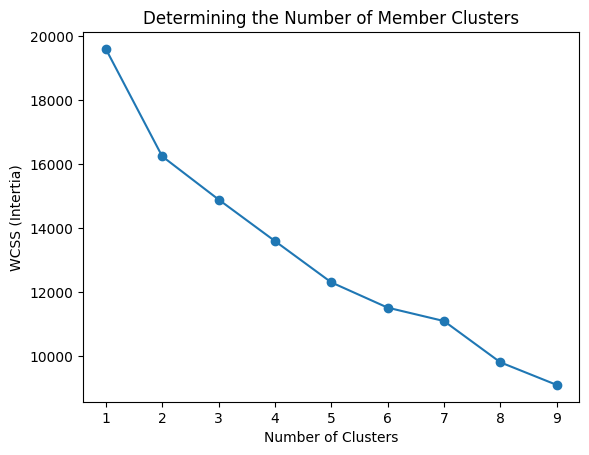

In [11]:
# Create the elbow plot to determine how many clusters to create
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Intertia)')
plt.title('Determining the Number of Member Clusters')
plt.show()

In [12]:
# Use the sihlouette score to help determine the ideal number of clusters
range_n_clusters = range(2, 10)

for i in range_n_clusters:
    clusterer = KMeans(n_clusters=i, random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)

    print(f'score for {i} clusters = {score}')

score for 2 clusters = 0.25735882861667503
score for 3 clusters = 0.15260595486312226
score for 4 clusters = 0.20897876853507313
score for 5 clusters = 0.2305494993935854
score for 6 clusters = 0.18815076124284139
score for 7 clusters = 0.19498321773525712
score for 8 clusters = 0.21948997377559487
score for 9 clusters = 0.21900745917285458


## Perform K-Means Clustering

In [13]:
# Based on the elbow plot and the sihlouette score, use 5 for the number of clusters
# Initialize and fit with 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
member_data_active['cluster'] = kmeans.fit_predict(X_scaled)

# Create the summary
cluster_summary = member_data_active.groupby('cluster')[member_features].mean()
cluster_summary['member_count'] = member_data_active.groupby('cluster').size()

print(cluster_summary)

         district_referral_count        age  original_join_tenure  \
cluster                                                             
0                       0.583055  57.122913              5.577261   
1                       1.018349  61.744790             21.836520   
2                       7.000000  69.172536             37.687576   
3                       2.814672  78.692031             35.505178   
4                       0.578723  45.363310              8.340507   

         true_lapses  current_chorus_count  former_chorus_count  \
cluster                                                           
0           0.000000              0.762542             0.305463   
1           1.201835              0.821101             0.871560   
2           0.107527              1.053763             2.161290   
3           0.005792              1.094595             0.646718   
4           0.114894              0.889362             0.310638   

         current_quartet_count  former_quartet

## Re-number the Clusters
The default output of the clusters does not put them in an intuitive order, for thinking about members along a spectrum of involvement. These should be rearranged to remove the indexing starting at 0, and ensure they follow a more intuitive order.

In [14]:
# Map the default clusters to labels from A to E
mapping = {
    0: 'A',
    1: 'B',
    2: 'E',
    3: 'C',
    4: 'D'
}

member_data_active['cluster_label'] = member_data_active['cluster'].map(mapping)

## Interpret the Clusters

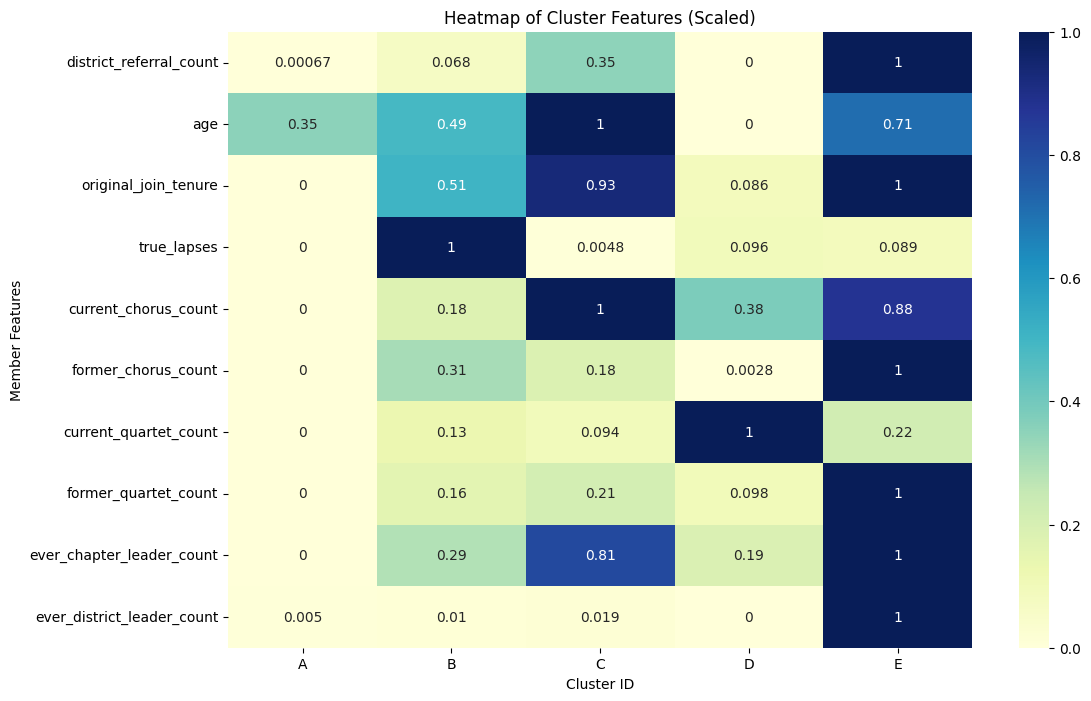

In [15]:
# Calculate the mean of each feature per cluster
cluster_means = member_data_active.groupby('cluster_label')[member_features].mean()

# Scale the means so they can be compared
cluster_means_scaled = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Visualize in a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_scaled.T, annot=True, cmap="YlGnBu")
plt.title('Heatmap of Cluster Features (Scaled)')
plt.ylabel('Member Features')
plt.xlabel('Cluster ID')
plt.show()

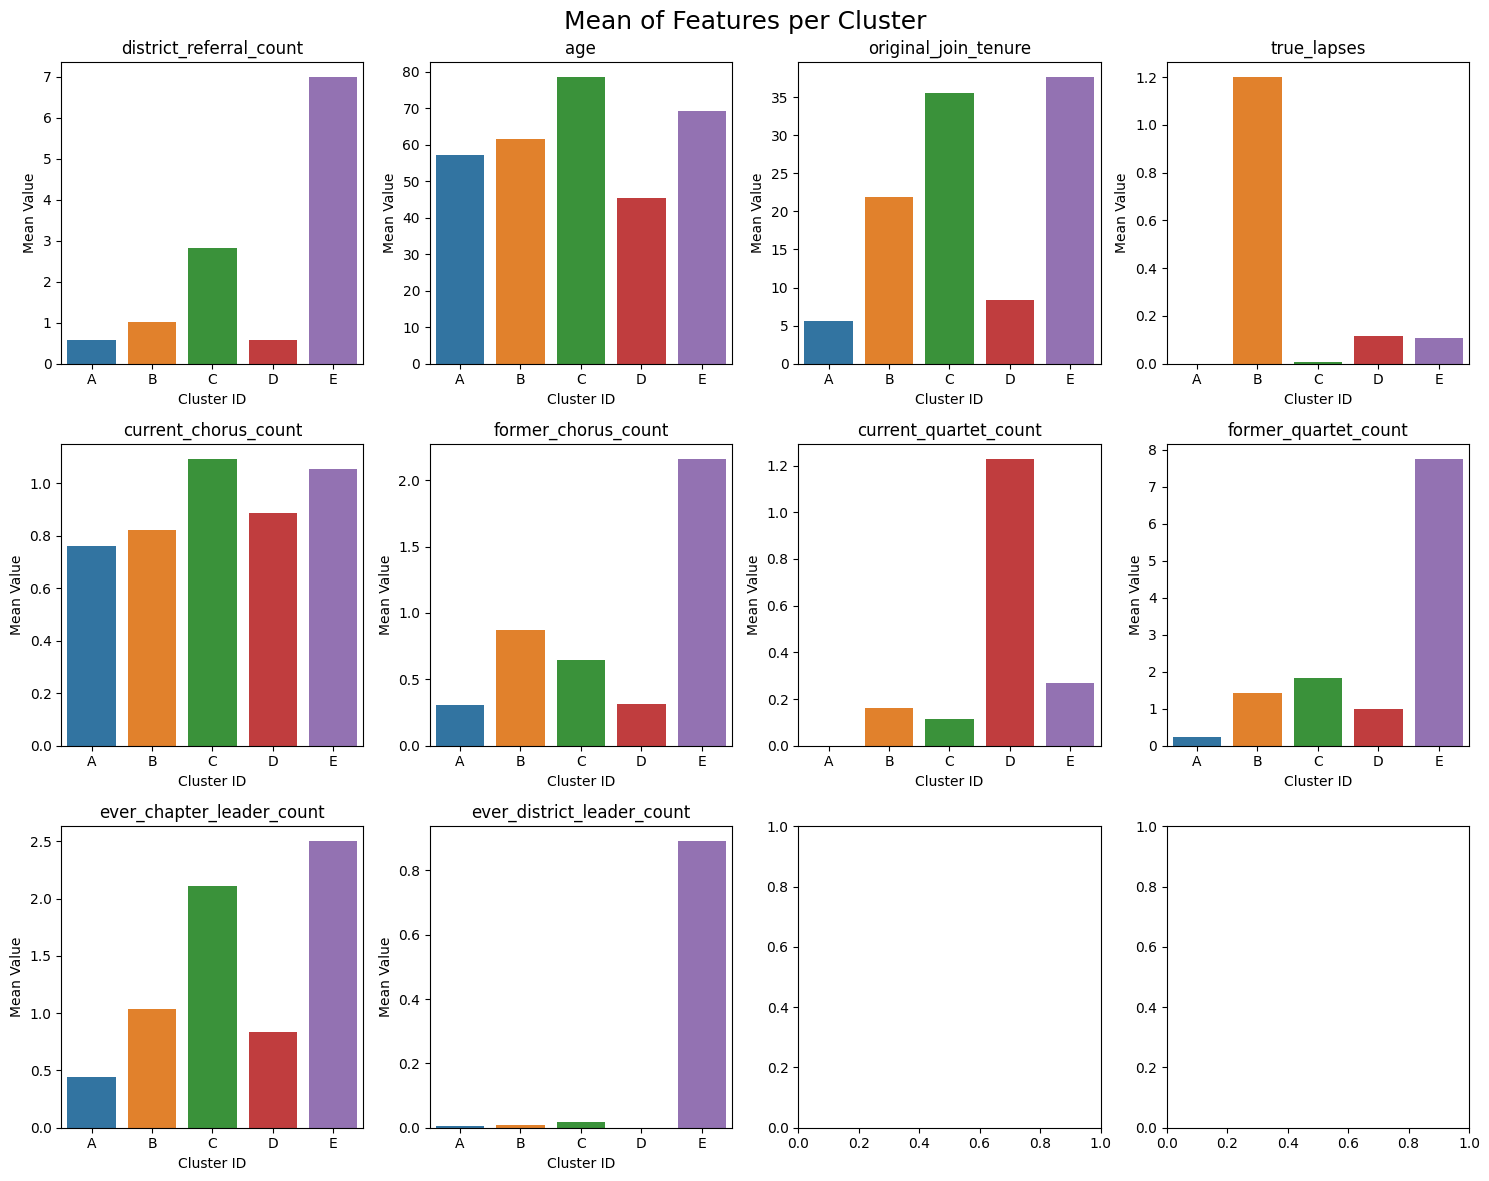

In [16]:
# Visualize the mean of each feature for each cluster in bar charts
fig, axes = plt.subplots(3,4, figsize=(15,12))
axe = axes.ravel()

# Define the order for the bars
order = ['A', 'B', 'C', 'D', 'E']

for i, col in enumerate(member_features):
    sns.barplot(data=member_data_active,
                x='cluster_label',
                y=col,
                ax=axe[i],
                hue='cluster_label',
                palette='tab10',
                legend=False,
                order=order,
                hue_order=order,
                errorbar=None)
    axe[i].set_title(col)
    axe[i].set_xlabel('Cluster ID')
    axe[i].set_ylabel('Mean Value')

plt.suptitle('Mean of Features per Cluster', fontsize=18)
plt.tight_layout()
plt.show()

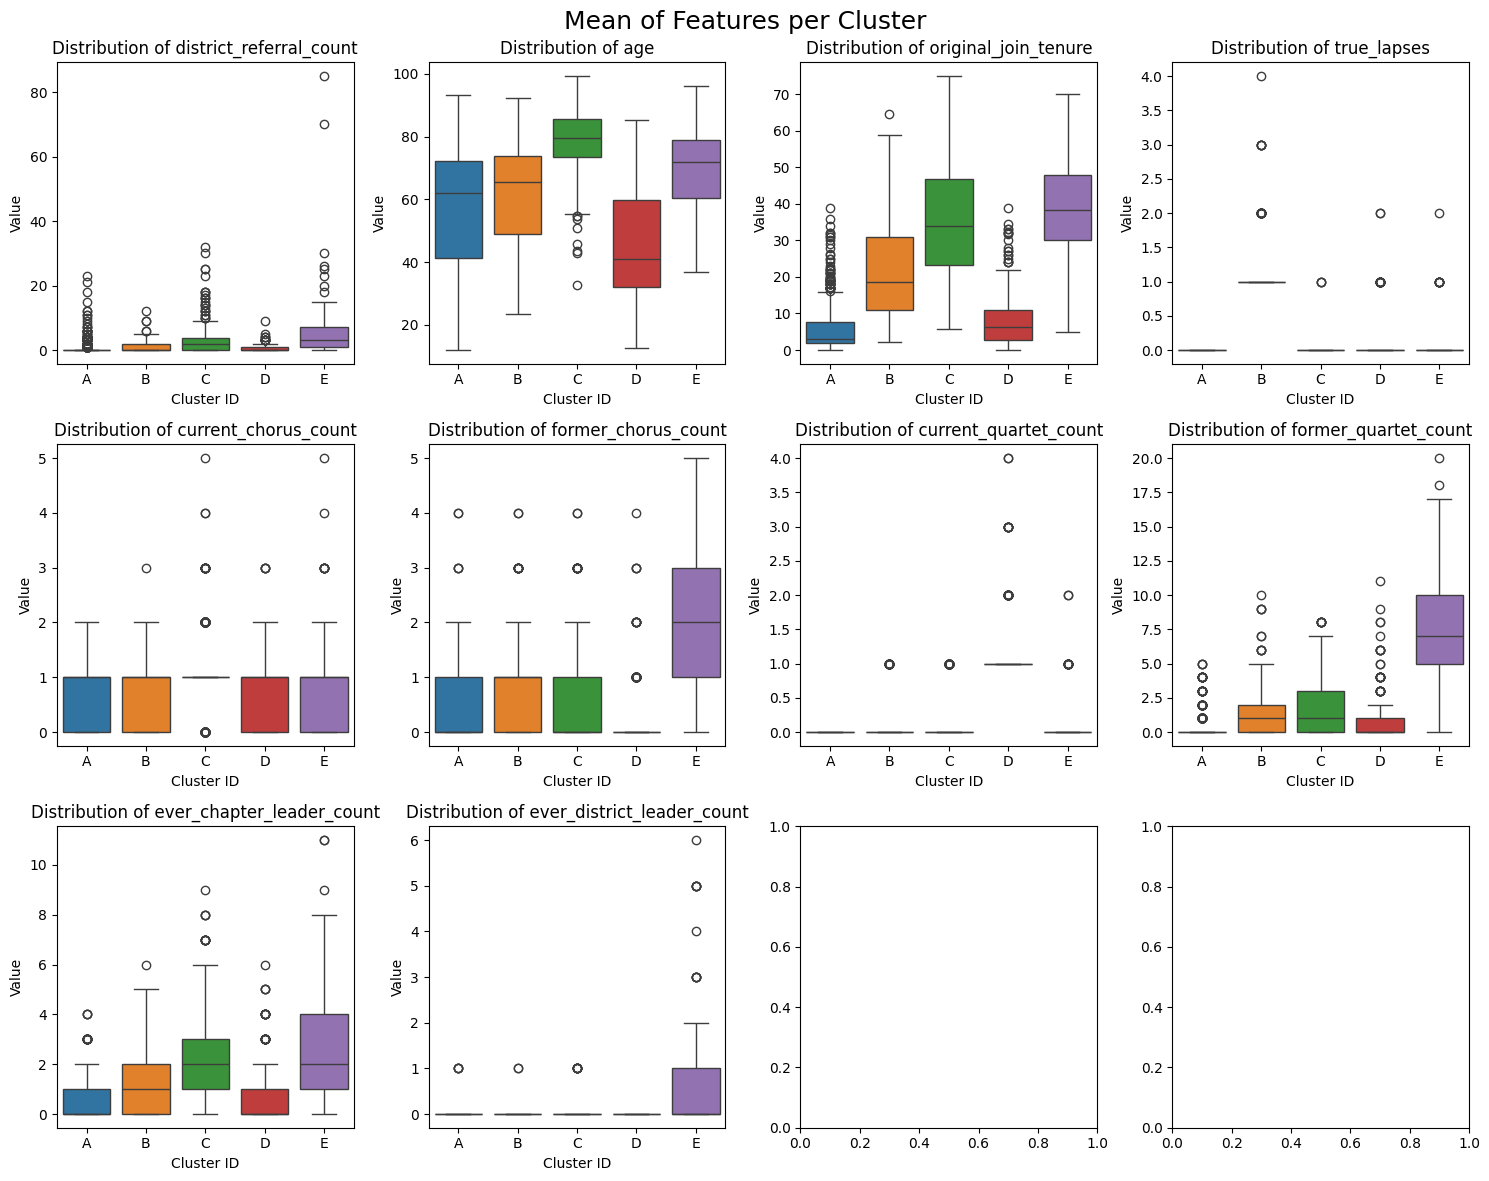

In [17]:
# Visualize the mean of each feature for each cluster in box and whisker plot
fig, axes = plt.subplots(3,4, figsize=(15,12))
axe = axes.ravel()

for i, col in enumerate(member_features):
    sns.boxplot(x='cluster_label',
                y=col,
                data=member_data_active,
                ax=axe[i],
                hue='cluster_label',
                palette='tab10',
                legend=False,
                order=order,
                hue_order=order)
    axe[i].set_title(f'Distribution of {col}')
    axe[i].set_xlabel('Cluster ID')
    axe[i].set_ylabel('Value')

plt.suptitle('Mean of Features per Cluster', fontsize=18)
plt.tight_layout()
plt.show()

In [18]:
# Print the summary of each persona, along with key mean values
print('The clusters can be labeled as such, based on the heatmap and values:\n(Note that all values included below are the mean value for the cluster.)\n')

print('-'*10)
print(f'Cluster A: "New & Uninvolved" - New Members with Low Participation ({cluster_summary.loc[0,'member_count']} members)\n - Description: These members are younger (age = {cluster_summary.loc[0,'age']:.0f}) and are new to being involved in barbershop (tenure = {cluster_summary.loc[0,'original_join_tenure']:.1f} years). Their current participation is low in both choruses (current_chorus_count = {cluster_summary.loc[0,'current_chorus_count']:.1f}) and quartets (current_quartet_count = {cluster_summary.loc[0,'current_quartet_count']:.1f}). Past participation is also low in both choruses (former_chorus_count = {cluster_summary.loc[0,'former_chorus_count']:.1f}) and quartets (former_quartet_count = {cluster_summary.loc[0,'former_quartet_count']:.1f}).\n - Actions: These members are a retention risk because they are barely involved. They should be encouraged to join a chorus and/or quartet in order to get more value out of the hobby.\n')

print('-'*10)
print(f'Cluster B: "Sporadic Members" - Members with Multiple Lapses and Former Involvement ({cluster_summary.loc[1,'member_count']} members)\n - Description: These members are older (age = {cluster_summary.loc[1,'age']:.0f}) and have not been involved for a relatively long time (tenure = {cluster_summary.loc[1,'original_join_tenure']:.1f} years), but stand out because of their high number of membership lapses as compared to other groups (lapses = {cluster_summary.loc[1,'true_lapses']:.1f}). They have been involved in the past in a chorus (former_chorus_count = {cluster_summary.loc[1,'former_chorus_count']:.1f}) and multiple quartets (former_quartet_count = {cluster_summary.loc[1,'former_quartet_count']:.1f}), but are not currently very involved in either (current_chorus_count = {cluster_summary.loc[1,'current_chorus_count']:.1f}, current_quartet_count = {cluster_summary.loc[1,'current_quartet_count']:.1f}).\n - Actions: These members have gone in and out of their involvement. This could be due to life reasons, or just because they were not invested in the hobby. This group is also a retention risk, because they might be letting their membership lapse because they are not getting enough value from the hobby.\n')

print('-'*10)
print(f'Cluster C: "Backbone" - Long-Time Members with Low Involvement ({cluster_summary.loc[3,'member_count']} members)\n - Description: These members are older (age = {cluster_summary.loc[3,'age']:.0f}) and have been involved for a long time (tenure = {cluster_summary.loc[3,'original_join_tenure']:.1f} years). They are currently and formerly active in a chorus (current_chorus_count = {cluster_summary.loc[3,'current_chorus_count']:.1f}, former_chorus_count = {cluster_summary.loc[3,'former_chorus_count']:.1f}) but are not currently active in quartets (current_quartet_count = {cluster_summary.loc[3,'current_quartet_count']:.1f}). There is some amount of involvement in chapter leadership (ever_chapter_leadership_count = {cluster_summary.loc[3,'ever_chapter_leader_count']:.1f}) but not in district leadership (ever_district_leader_count = {cluster_summary.loc[3,'ever_district_leader_count']:.1f}).\n - Actions: These members are steady members of a single chorus. They should be looked at for chapter leadership as a way to get more involved in the hobby, especially since they are likely retired and have spare time.\n')

print('-'*10)
print(f'Cluster D: "Rising Stars" - Younger Members with High Involvement in Choruses, Quartets, and Chapter Leadership ({cluster_summary.loc[4,'member_count']} members)\n - Description: These members are younger (age = {cluster_summary.loc[4,'age']:.0f}) and are relatively new to the hobby (tenure = {cluster_summary.loc[4,'original_join_tenure']:.1f} years). They are involved in a chorus (current_chorus_count = {cluster_summary.loc[4,'current_chorus_count']:.1f}), quartets (current_quartet_count = {cluster_summary.loc[4,'current_quartet_count']:.1f}), and are starting to get involved in chapter leadership (ever_chapter_leadership_count = {cluster_summary.loc[4,'ever_chapter_leader_count']:.1f}).\n - Actions: This group is primed to be tapped for district leadership and other chapter leadership roles. They are dedicated to the hobby and already have experience in both choruses and quartets, and have some experience already in chapter leadership. They joined the hobby young and should be given opportunities to get involved in different ways, so they evolve into the "super users" of Cluster 2.\n')

print('-'*10)
print(f'Cluster E: "Super Users" - Long-Time Members with Heavy Involvement in Leadership and Choruses ({cluster_summary.loc[2,'member_count']} members)\n - Description: These members are highly involved and are the ones who keep everything running. They are older (age = {cluster_summary.loc[2,'age']:.0f}) and have been involved for a long time (tenure = {cluster_summary.loc[2]['original_join_tenure']:.1f} years). They sing with multiple choruses (current_chorus_count = {cluster_summary.loc[2,'current_chorus_count']:.1f}) but not many quartets (current_quartet_count = {cluster_summary.loc[2,'current_quartet_count']:.1f}). They are currently or formerly involved in district leadership (ever_district_leader_count = {cluster_summary.loc[2,'ever_district_leader_count']:.1f}) and chapter leadership (ever_chapter_leadership_count = {cluster_summary.loc[2,'ever_chapter_leader_count']:.1f}). Additionally, they recommend many other people to join the hobby (district_referral_count = {cluster_summary.loc[2,'district_referral_count']:.1f}).\n - Actions: These members are highly dedicated in their own involvement, and they bring new members into the hobby. Those who have not been involved in chapter leadership or district leadership should be tapped for these roles, since they have a wealth of experience to contribute. They should also be encouraged to continue to recommend new members so the hobby can continue growing.\n')

The clusters can be labeled as such, based on the heatmap and values:
(Note that all values included below are the mean value for the cluster.)

----------
Cluster A: "New & Uninvolved" - New Members with Low Participation (897 members)
 - Description: These members are younger (age = 57) and are new to being involved in barbershop (tenure = 5.6 years). Their current participation is low in both choruses (current_chorus_count = 0.8) and quartets (current_quartet_count = 0.0). Past participation is also low in both choruses (former_chorus_count = 0.3) and quartets (former_quartet_count = 0.2).
 - Actions: These members are a retention risk because they are barely involved. They should be encouraged to join a chorus and/or quartet in order to get more value out of the hobby.

----------
Cluster B: "Sporadic Members" - Members with Multiple Lapses and Former Involvement (218 members)
 - Description: These members are older (age = 62) and have not been involved for a relatively long time (

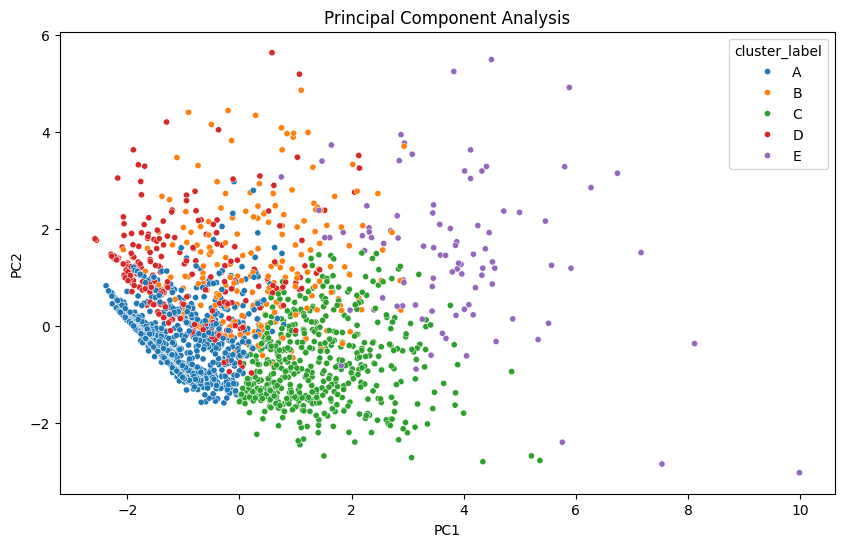

In [19]:
# Use Principal Component Analysis to reduce the features down to 2 dimensions
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# Convert to DataFrame for visualization
pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
pca_df['cluster_label'] = member_data_active['cluster_label'].values

# Visualize in a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster_label', hue_order=order, data=pca_df, s=20, palette='tab10')
plt.title('Principal Component Analysis')
plt.show()

**PCA Interpretation**

The visualization of Principal Component Analysis above shows that clusters A and C are the most distinct, while the other clusters have more overlap. This is to be expected because the sihlouette score is relatively low. However, a careful interpretation of the means and spread of each feature still provide distinct enough personas for this particular business problem.

## Identify Specific Members for Leadership and for Retention

Once the clusters are identified, the members of each can be further filtered in order to identify members to prioritize in various categories. This can be run as a proof-of-concept here before being fully built into a separate pipeline notebook.

### District Leadership
Members of Cluster E are heavily involved, and many have already held chapter leadership roles. Identifying the people in this cluster who have not yet held district leadership roles provides a list of people to potentially nominate for these roles.

In [20]:
# Identify members of Cluster E who currently or formerly hold chapter leadership but have not previously held district leadership, and therefore might be ready to be "promoted" to a higher-level leadership role
# Filter to members age 65 and below, since younger members are more likely to have the mental capacity for fast-moving district leadership work, and are more likely to remain in the role for longer
# Sort by number of chapter leadership roles, current and then former
# Highlight the top ten members with only relevant columns
member_data_active[(member_data_active['cluster_label']=='E') & (member_data_active['ever_district_leader_count']==0) & (member_data_active['age']<=65) & ((member_data_active['current_chapter_leader_count']>0) | (member_data_active['former_chapter_leader_count']>0))].sort_values(by=['current_chapter_leader_count','former_chapter_leader_count'], ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure', 'current_chapter_leader_count', 'former_chapter_leader_count', 'district_referral_count']][:10]

,member_number,age,gender,original_join_tenure,current_chapter_leader_count,former_chapter_leader_count,district_referral_count
1735,Num_4962,63.241615,Male,36.996578,4,2,6
2242,Num_2647,50.253251,Male,18.529774,2,2,13
1256,Num_2383,63.206023,Male,41.995893,1,6,4
2970,Num_5097,45.054073,Male,24.996578,1,4,14
2367,Num_3120,41.637235,Male,30.535250,1,3,0
1899,Num_4449,62.527036,Male,48.996578,1,2,0
1025,Num_3541,57.464750,Male,34.617385,1,1,2
1464,Num_572,53.670089,Male,46.995209,1,0,2
2152,Num_1747,47.638604,Male,30.825462,1,0,8
2882,Num_3376,45.007529,Male,23.997262,1,0,4


### Chapter Leadership
Members of Cluster E have often already held chapter leadership roles, but any who have not would be excellent candidates. In addition, members of Cluster D are younger members with high involvement, who should be tapped for chapter leadership roles.

In [21]:
# Identify members of Cluster E who have not yet held chapter leadership but are highly involved and might be ready to get involved in leadership
# Also identify members of Cluster D who are not currently in chapter leadership
# Filter to members age 65 and below, since younger members are more likely to have the mental capacity for fast-moving chapter leadership work, and are more likely to remain in the role for longer
# Sort by tenure
# Highlight the top ten members with only relevant columns

member_data_active[((member_data_active['cluster_label']=='E') | (member_data_active['cluster_label']=='D')) & (member_data_active['former_chapter_leader_count']==0) & (member_data_active['current_chapter_leader_count']==0) & (member_data_active['age']<=65)].sort_values(by='original_join_tenure', ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure']][:10]

,member_number,age,gender,original_join_tenure
1273,Num_1477,59.526352,Male,38.995209
1839,Num_1460,64.774812,Male,32.547570
2107,Num_1361,57.445585,Male,32.188912
1075,Num_1504,60.087611,Male,27.997262
2912,Num_2751,57.089665,Male,26.997947
3428,Num_1831,36.722793,Male,22.455852
3520,Num_1067,42.316222,Male,20.996578
4201,Num_2755,40.005476,Male,17.995893
4039,Num_4329,63.518138,Male,17.995893
4437,Num_3712,39.679671,Male,16.449008


### Retention

Members of Cluster A are relatively new to the hobby but have barely been involved. They should be encouraged to join a chorus and/or quartet in order to get value from their membership.

In [22]:
# Identify members of Cluster A who are not currently in any choruses or any quartets but may have been in the past
# Sort by tenure, since members with longer tenure have held onto their membership for a reason and might need a nudge to get more involved, while the newest members might still be finding the right group for them
# Highlight the top ten members with only relevant columns

member_data_active[(member_data_active['cluster_label']=='A') & (member_data_active['current_chorus_count']==0) & (member_data_active['current_quartet_count']==0)].sort_values(by='original_join_tenure', ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure', 'former_chorus_count', 'former_quartet_count']][:10]

,member_number,age,gender,original_join_tenure,former_chorus_count,former_quartet_count
1532,Num_5972,60.903491,Male,38.997947,0,3
1406,Num_4142,49.691992,Male,35.824778,1,0
2031,Num_2217,68.262834,Male,33.998631,0,1
1499,Num_6703,64.583162,Male,31.594798,0,1
2270,Num_2811,79.928816,Male,30.995209,0,1
2540,Num_4040,74.422998,Male,27.997262,0,1
873,Num_133,79.356605,Male,24.999316,1,0
1415,Num_5750,72.506502,Male,21.995893,1,1
3482,Num_2738,46.559890,Male,21.133470,1,0
3416,Num_672,85.314168,Male,20.996578,1,0


In [23]:
# Identify members of Cluster A who joined within the last 3 years but have not yet joined any choruses or quartets, and are therefore at risk of leaving because they haven't actually gotten involved yet
# Filter out members with a long Years of Service, which refers to overall duration in the society, not in this specific district, since these members likely recently moved into this district and are not actually a retention risk
# Highlight the top ten members with only relevant columns

member_data_active[(member_data_active['cluster_label']=='A') & (member_data_active['current_chorus_count']==0) & (member_data_active['former_chorus_count']==0) & (member_data_active['current_quartet_count']==0) & (member_data_active['former_quartet_count']==0) & (member_data_active['original_join_tenure']<3) & (member_data_active['district_status']=='Current') & (member_data_active['years_of_service']<3)].sort_values(by='original_join_tenure', ascending=False)[['member_number', 'age', 'gender', 'original_join_tenure']][:10]

,member_number,age,gender,original_join_tenure
7086,Num_6352,78.644764,Male,1.998631
7114,Num_1284,23.567420,Male,1.998631
7153,Num_4349,57.631759,Female,1.998631
7168,Num_5635,41.289528,Female,1.998631
7146,Num_3339,22.001369,Male,1.330595
7250,Num_4664,69.787817,Female,0.999316
7259,Num_3475,35.154004,Male,0.999316
7260,Num_6134,74.759754,Male,0.999316
7302,Num_5182,61.579740,Male,0.999316
7326,Num_3738,38.291581,Female,0.999316


## Prepare the Model for a Separate Pipeline

In [24]:
# Save the scaler and the model to files for use in a separate pipeline notebook
import joblib
joblib.dump(scaler, 'cluster_scaler.pkl')
joblib.dump(kmeans, 'cluster_kmeans_model.pkl')

['cluster_kmeans_model.pkl']